# Inicio del proyecto

In [1]:
import pandas as pd

df = pd.read_csv(
    "data/steel.csv",
    encoding="latin1"
)

df.head()

,SAE Grade,Conditions,UTS (MPa),UTS (Ksi),YS (MPa),YS (ksi),Elongation (%),Reduction (%),Hardness (HB),C (Min),...,Si (Min),Si (Max),Ni (Min),Ni (Max),Cr (Min),Cr (Max),Mo (Min),Mo (Max),Ti (Min),Ti (Max)
0,1006,Hot rolled,295,43,165,24,30.0,55,86,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1006,Cold drawn,330,48,285,41,20.0,45,95,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1008,Hot rolled,305,44,170,24.5,30.0,55,86,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1008,Cold drawn,340,49,285,42,20.0,45,95,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1010,Hot rolled,325,47,180,26,28.0,50,95,0.08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df.columns
#Columnas del dataframe

Index(['SAE Grade', 'Conditions', 'UTS (MPa)', 'UTS (Ksi)', 'YS (MPa)',
       'YS (ksi)', 'Elongation (%)', 'Reduction (%)', 'Hardness (HB)',
       'C (Min)', 'C (Max)', 'Mn (Min)', 'Mn (Max)', 'P (Min)', 'P (Max)',
       'S (Min)', 'S(Max)', 'Si (Min)', 'Si (Max)', 'Ni (Min)', 'Ni (Max)',
       'Cr (Min)', 'Cr (Max)', 'Mo (Min)', 'Mo (Max)', 'Ti (Min)', 'Ti (Max)'],
      dtype='object')

In [3]:
df.isnull().sum()
#Cantidad de NaNs (Datos vacios) por columna 

SAE Grade           0
Conditions          0
UTS (MPa)           0
UTS (Ksi)           0
YS (MPa)            0
YS (ksi)            0
Elongation (%)      0
Reduction (%)       0
Hardness (HB)       0
C (Min)            12
C (Max)             0
Mn (Min)            0
Mn (Max)            0
P (Min)           187
P (Max)             0
S (Min)           162
S(Max)              0
Si (Min)          183
Si (Max)          183
Ni (Min)          183
Ni (Max)          183
Cr (Min)          183
Cr (Max)          183
Mo (Min)          185
Mo (Max)          185
Ti (Min)          190
Ti (Max)          190
dtype: int64

In [4]:
df.count()
#Cantidad de datos reales por columna

SAE Grade         190
Conditions        190
UTS (MPa)         190
UTS (Ksi)         190
YS (MPa)          190
YS (ksi)          190
Elongation (%)    190
Reduction (%)     190
Hardness (HB)     190
C (Min)           178
C (Max)           190
Mn (Min)          190
Mn (Max)          190
P (Min)             3
P (Max)           190
S (Min)            28
S(Max)            190
Si (Min)            7
Si (Max)            7
Ni (Min)            7
Ni (Max)            7
Cr (Min)            7
Cr (Max)            7
Mo (Min)            5
Mo (Max)            5
Ti (Min)            0
Ti (Max)            0
dtype: int64

In [5]:
# Eliminar columnas con muchos NaNs y que no utilizamos porque puede afectar rendimiento y bueno para limpieza de datos

df = df.drop(columns=[
    "P (Min)",
    "S (Min)",
    "Si (Min)",
    "Si (Max)",
    "Ni (Min)",
    "Ni (Max)",
    "Cr (Min)",
    "Cr (Max)",
    "Mo (Min)",
    "Mo (Max)",
    "Ti (Min)",
    "Ti (Max)"
])

# Verificar columnas restantes
print(df.columns)

Index(['SAE Grade', 'Conditions', 'UTS (MPa)', 'UTS (Ksi)', 'YS (MPa)',
       'YS (ksi)', 'Elongation (%)', 'Reduction (%)', 'Hardness (HB)',
       'C (Min)', 'C (Max)', 'Mn (Min)', 'Mn (Max)', 'P (Max)', 'S(Max)'],
      dtype='object')


In [6]:
df.head() 
#Tabla sin columna repleta de mas del 30% de NaNs.

,SAE Grade,Conditions,UTS (MPa),UTS (Ksi),YS (MPa),YS (ksi),Elongation (%),Reduction (%),Hardness (HB),C (Min),C (Max),Mn (Min),Mn (Max),P (Max),S(Max)
0,1006,Hot rolled,295,43,165,24,30.0,55,86,NaN,0.08,0.25,0.4,0.04,0.05
1,1006,Cold drawn,330,48,285,41,20.0,45,95,NaN,0.08,0.25,0.4,0.04,0.05
2,1008,Hot rolled,305,44,170,24.5,30.0,55,86,NaN,0.10,0.30,0.5,0.04,0.05
3,1008,Cold drawn,340,49,285,42,20.0,45,95,NaN,0.10,0.30,0.5,0.04,0.05
4,1010,Hot rolled,325,47,180,26,28.0,50,95,0.08,0.13,0.30,0.5,0.04,0.05


In [7]:
df["C_pct"] = (df["C (Min)"] + df["C (Max)"]) / 2

df[["C (Min)", "C (Max)", "C_pct"]].head()

,C (Min),C (Max),C_pct
0,NaN,0.08,NaN
1,NaN,0.08,NaN
2,NaN,0.10,NaN
3,NaN,0.10,NaN
4,0.08,0.13,0.105


In [8]:
df["C_pct"] = df[["C (Min)", "C (Max)"]].mean(axis=1)

df[["C (Min)", "C (Max)", "C_pct"]].head()

,C (Min),C (Max),C_pct
0,NaN,0.08,0.080
1,NaN,0.08,0.080
2,NaN,0.10,0.100
3,NaN,0.10,0.100
4,0.08,0.13,0.105


In [9]:
def clasificar_tratamiento(cond):

    cond = str(cond).lower()

    if "annealed" in cond:
        return "Annealed"

    elif "normalized" in cond:
        return "Normalized"

    elif "hot rolled" in cond:
        return "Hot Rolled"

    elif "cold drawn" in cond:
        return "Cold Drawn"

    elif "quenched" in cond:
        return "Quenched"

    elif "spheroidized" in cond:
        return "Spheroidized"

    elif "oi" in cond:
        return "Other"

    else:
        return "Other"


# Crear columna simplificada
df["Condition_simple"] = df["Conditions"].apply(clasificar_tratamiento)

# Verificar resultados
df[["Conditions", "Condition_simple"]].head(15)

,Conditions,Condition_simple
0,Hot rolled,Hot Rolled
1,Cold drawn,Cold Drawn
2,Hot rolled,Hot Rolled
3,Cold drawn,Cold Drawn
4,Hot rolled,Hot Rolled
5,Cold drawn,Cold Drawn
6,Hot rolled,Hot Rolled
7,Cold drawn,Cold Drawn
8,Hot rolled,Hot Rolled
9,Cold drawn,Cold Drawn


# Primera pregunta: ¿Cómo cambian las propiedades mecánicas con el  contenido de carbono? 

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df["Hardness (HB)"] = (
    df["Hardness (HB)"]
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

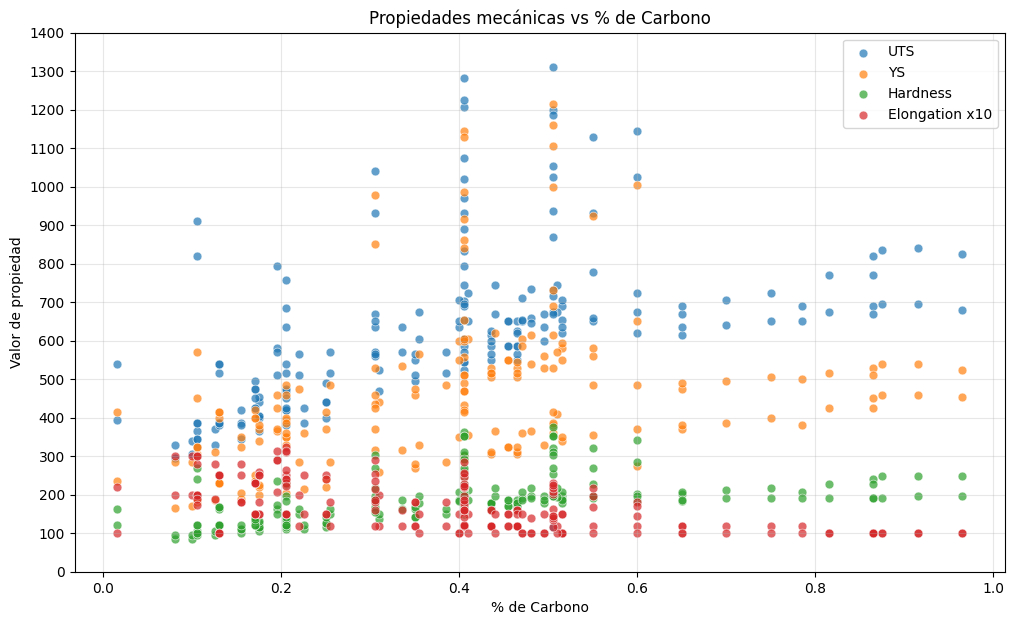

In [12]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x="C_pct",
    y="UTS (MPa)",
    label="UTS",
    alpha=0.7,
    s=40
)

sns.scatterplot(
    data=df,
    x="C_pct",
    y="YS (MPa)",
    label="YS",
    alpha=0.7,
    s=40
)

sns.scatterplot(
    data=df,
    x="C_pct",
    y="Hardness (HB)",
    label="Hardness",
    alpha=0.7,
    s=40
)

sns.scatterplot(
    data=df,
    x="C_pct",
    y=df["Elongation (%)"] * 10,
    label="Elongation x10",
    alpha=0.7,
    s=40
)

plt.title("Propiedades mecánicas vs % de Carbono")

plt.xlabel("% de Carbono")
plt.ylabel("Valor de propiedad")

plt.yticks(range(0, 1401, 100))

plt.grid(True, alpha=0.3)

plt.legend()

plt.show()

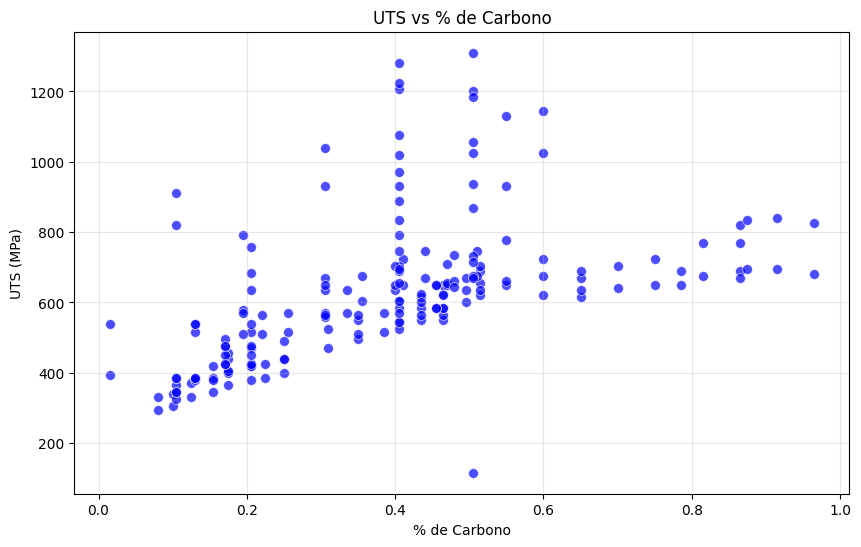

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="C_pct",
    y="UTS (MPa)",
    color="blue",
    alpha=0.7,
    s=50
)

plt.title("UTS vs % de Carbono")

plt.xlabel("% de Carbono")
plt.ylabel("UTS (MPa)")

plt.grid(True, alpha=0.3)

plt.show()

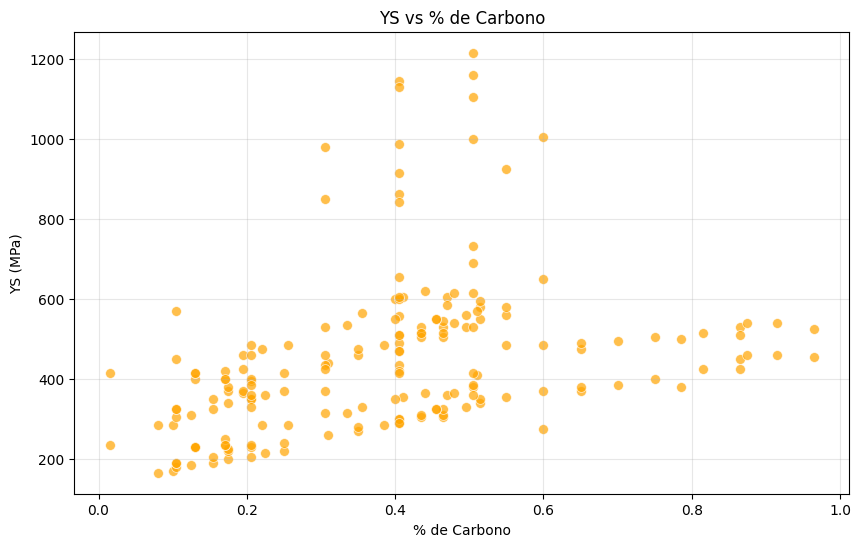

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="C_pct",
    y="YS (MPa)",
    color="orange",
    alpha=0.7,
    s=50
)

plt.title("YS vs % de Carbono")

plt.xlabel("% de Carbono")
plt.ylabel("YS (MPa)")

plt.grid(True, alpha=0.3)

plt.show()

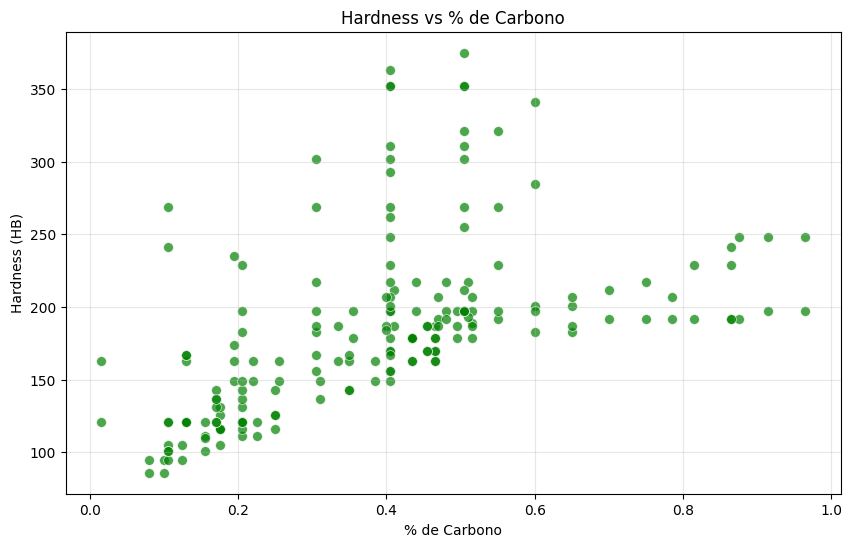

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="C_pct",
    y="Hardness (HB)",
    color="green",
    alpha=0.7,
    s=50
)

plt.title("Hardness vs % de Carbono")

plt.xlabel("% de Carbono")
plt.ylabel("Hardness (HB)")

plt.grid(True, alpha=0.3)

plt.show()

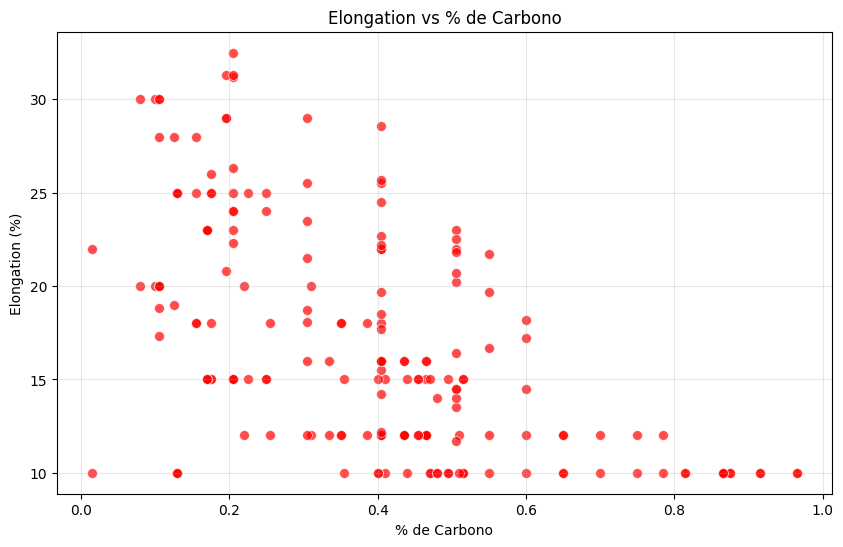

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="C_pct",
    y="Elongation (%)",
    color="red",
    alpha=0.7,
    s=50
)

plt.title("Elongation vs % de Carbono")

plt.xlabel("% de Carbono")
plt.ylabel("Elongation (%)")

plt.grid(True, alpha=0.3)

plt.show()

In [17]:
df["C_round"] = df["C_pct"].round(1)

In [18]:
df_group = df.groupby("C_round").agg({
    "UTS (MPa)": "mean",
    "YS (MPa)": "mean",
    "Hardness (HB)": "mean",
    "Elongation (%)": "mean"
}).reset_index()

df_group

,C_round,UTS (MPa),YS (MPa),Hardness (HB),Elongation (%)
0,0.0,467.500000,325.000000,142.000000,16.000000
1,0.1,429.750000,292.750000,128.800000,21.805000
2,0.2,475.650000,328.250000,136.950000,21.817500
3,0.3,636.142857,477.428571,187.571429,18.164286
4,0.4,709.348837,522.581395,206.604651,16.023256
5,0.5,713.435897,545.025641,215.102564,14.097436
6,0.6,782.071429,528.857143,228.071429,14.000000
7,0.7,672.500000,440.000000,202.000000,11.000000
8,0.8,693.333333,454.166667,204.833333,10.666667
9,0.9,751.875000,489.375000,217.375000,10.000000


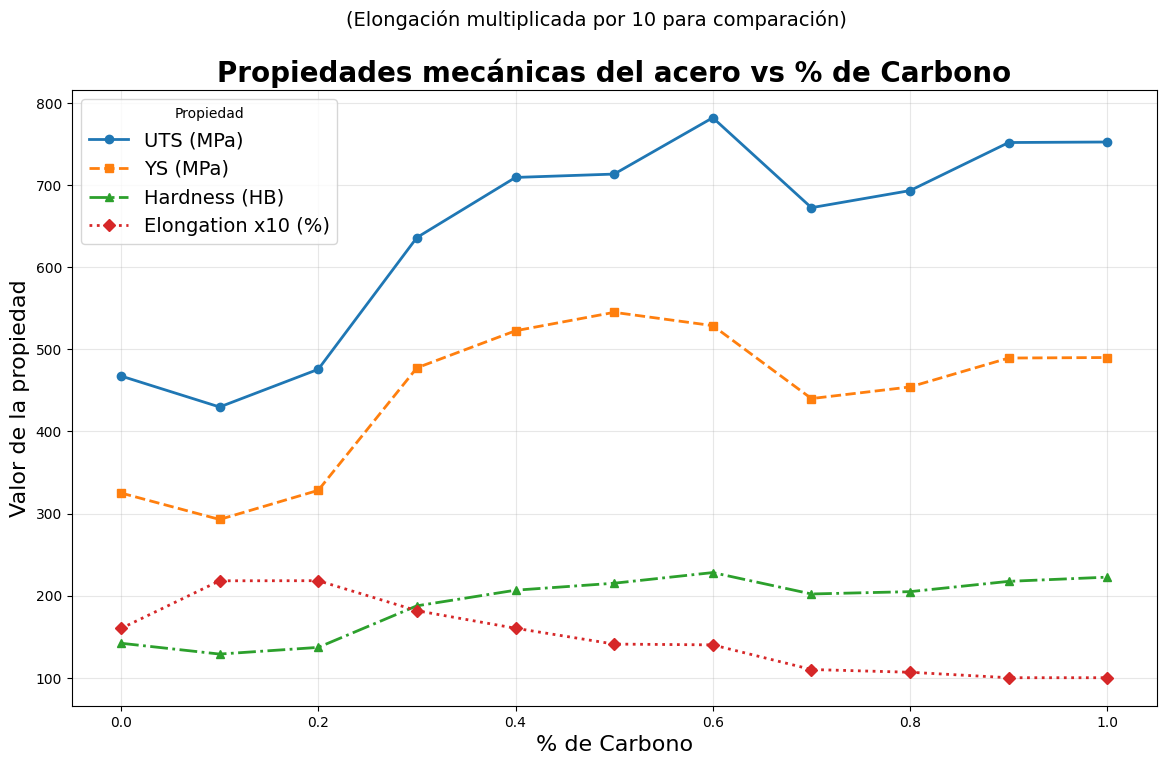

In [19]:
plt.figure(figsize=(14,8))

plt.plot(
    df_group["C_round"],
    df_group["UTS (MPa)"],
    marker="o",
    linewidth=2,
    label="UTS (MPa)"
)

plt.plot(
    df_group["C_round"],
    df_group["YS (MPa)"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="YS (MPa)"
)

plt.plot(
    df_group["C_round"],
    df_group["Hardness (HB)"],
    marker="^",
    linewidth=2,
    linestyle="-.",
    label="Hardness (HB)"
)

plt.plot(
    df_group["C_round"],
    df_group["Elongation (%)"] * 10,
    marker="D",
    linewidth=2,
    linestyle=":",
    label="Elongation x10 (%)"
)

plt.title(
    "Propiedades mecánicas del acero vs % de Carbono",
    fontsize=20,
    weight="bold"
)

plt.suptitle(
    "(Elongación multiplicada por 10 para comparación)",
    fontsize=14
)

plt.xlabel("% de Carbono", fontsize=16)
plt.ylabel("Valor de la propiedad", fontsize=16)

plt.grid(True, alpha=0.3)

plt.legend(title="Propiedad", fontsize=14)

plt.show()

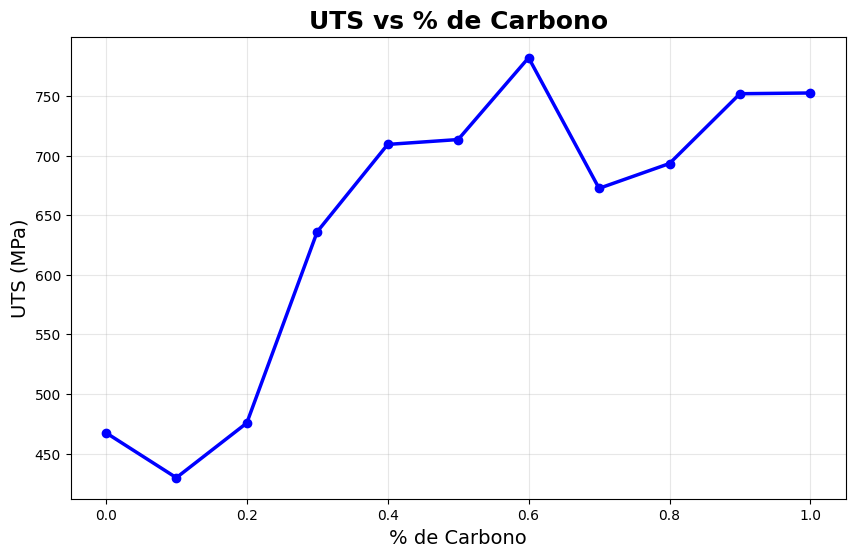

In [20]:
plt.figure(figsize=(10,6))

plt.plot(
    df_group["C_round"],
    df_group["UTS (MPa)"],
    marker="o",
    linewidth=2.5,
    color="blue"
)

plt.title(
    "UTS vs % de Carbono",
    fontsize=18,
    weight="bold"
)

plt.xlabel("% de Carbono", fontsize=14)
plt.ylabel("UTS (MPa)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.show()

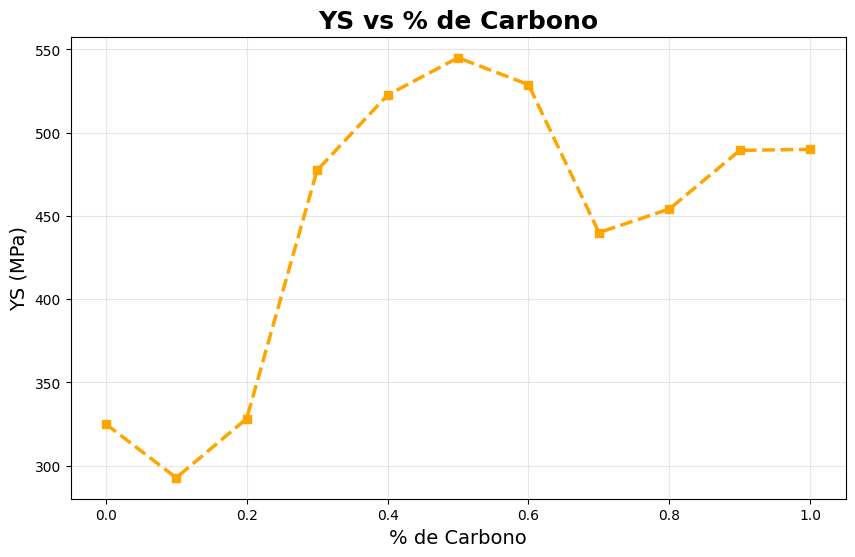

In [21]:
plt.figure(figsize=(10,6))

plt.plot(
    df_group["C_round"],
    df_group["YS (MPa)"],
    marker="s",
    linewidth=2.5,
    linestyle="--",
    color="orange"
)

plt.title(
    "YS vs % de Carbono",
    fontsize=18,
    weight="bold"
)

plt.xlabel("% de Carbono", fontsize=14)
plt.ylabel("YS (MPa)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.show()

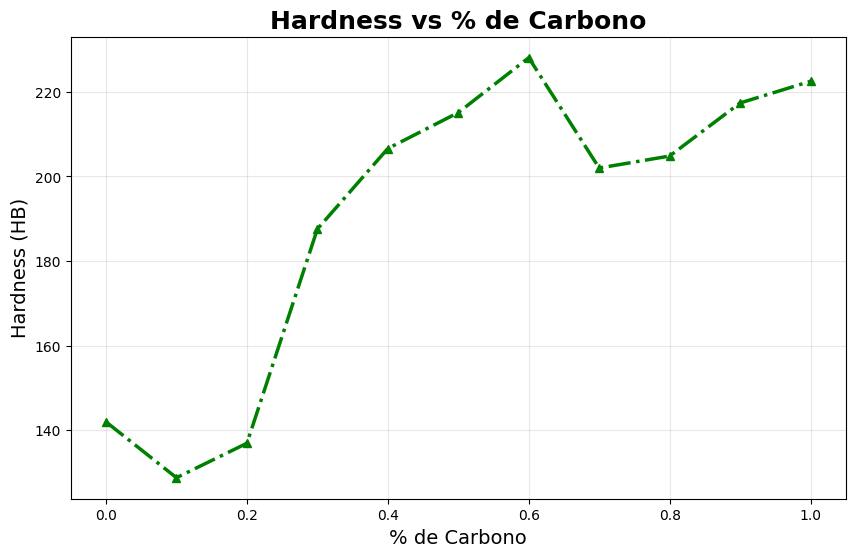

In [22]:
plt.figure(figsize=(10,6))

plt.plot(
    df_group["C_round"],
    df_group["Hardness (HB)"],
    marker="^",
    linewidth=2.5,
    linestyle="-.",
    color="green"
)

plt.title(
    "Hardness vs % de Carbono",
    fontsize=18,
    weight="bold"
)

plt.xlabel("% de Carbono", fontsize=14)
plt.ylabel("Hardness (HB)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.show()

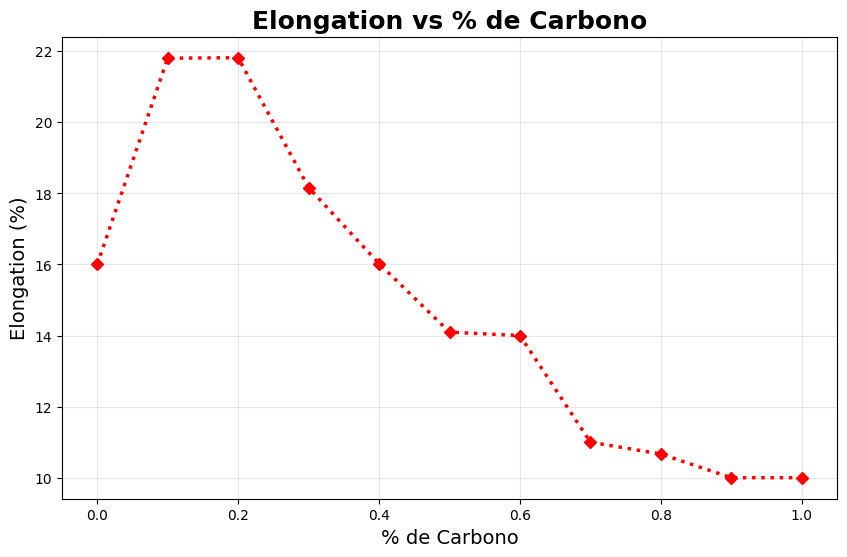

In [23]:
plt.figure(figsize=(10,6))

plt.plot(
    df_group["C_round"],
    df_group["Elongation (%)"],
    marker="D",
    linewidth=2.5,
    linestyle=":",
    color="red"
)

plt.title(
    "Elongation vs % de Carbono",
    fontsize=18,
    weight="bold"
)

plt.xlabel("% de Carbono", fontsize=14)
plt.ylabel("Elongation (%)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.show()

#  Segunda pregunta: efecto del tratamiento en cada propiedad 

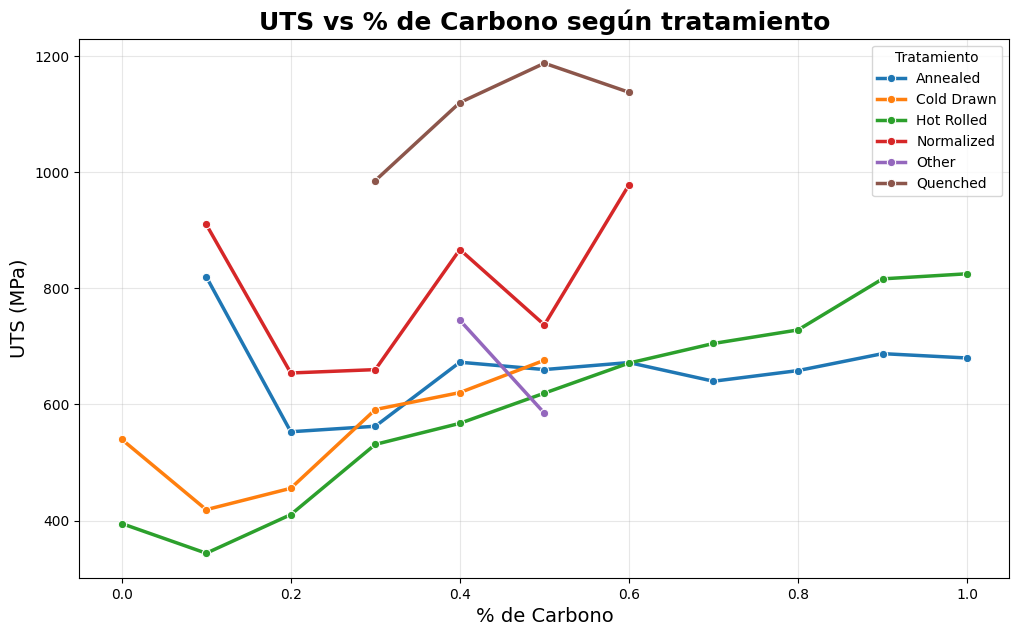

In [24]:
df_treat = df.groupby(
    ["Condition_simple", "C_round"]
)["UTS (MPa)"].mean().reset_index()

plt.figure(figsize=(12,7))

sns.lineplot(
    data=df_treat,
    x="C_round",
    y="UTS (MPa)",
    hue="Condition_simple",
    marker="o",
    linewidth=2.5
)

plt.title(
    "UTS vs % de Carbono según tratamiento",
    fontsize=18,
    weight="bold"
)

plt.xlabel("% de Carbono", fontsize=14)
plt.ylabel("UTS (MPa)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.legend(title="Tratamiento")

plt.show()

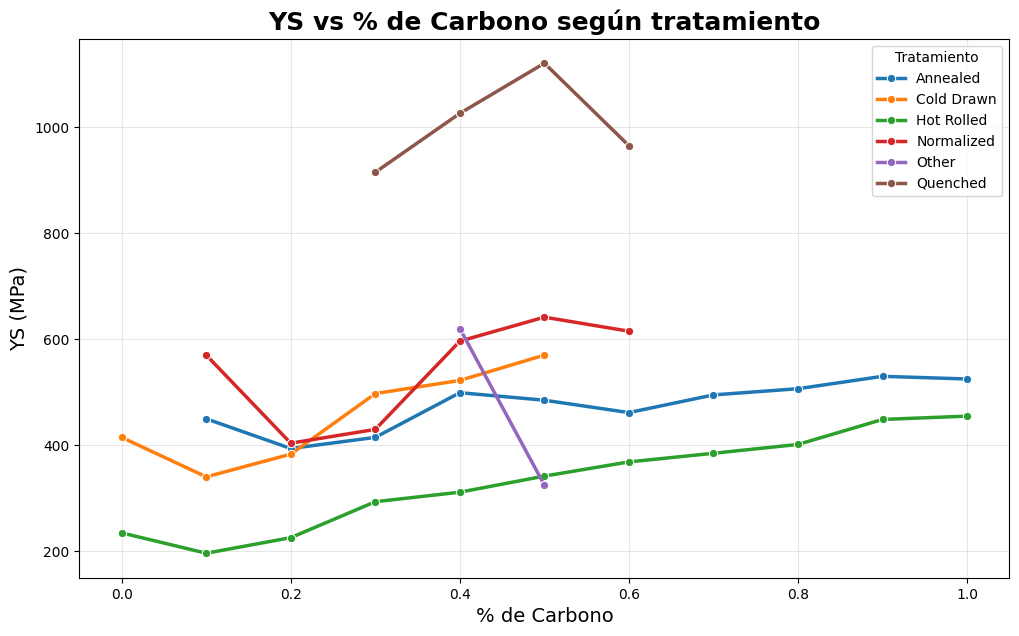

In [25]:
df_ys = df.groupby(
    ["Condition_simple", "C_round"]
)["YS (MPa)"].mean().reset_index()

plt.figure(figsize=(12,7))

sns.lineplot(
    data=df_ys,
    x="C_round",
    y="YS (MPa)",
    hue="Condition_simple",
    marker="o",
    linewidth=2.5
)

plt.title(
    "YS vs % de Carbono según tratamiento",
    fontsize=18,
    weight="bold"
)

plt.xlabel("% de Carbono", fontsize=14)
plt.ylabel("YS (MPa)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.legend(title="Tratamiento")

plt.show()

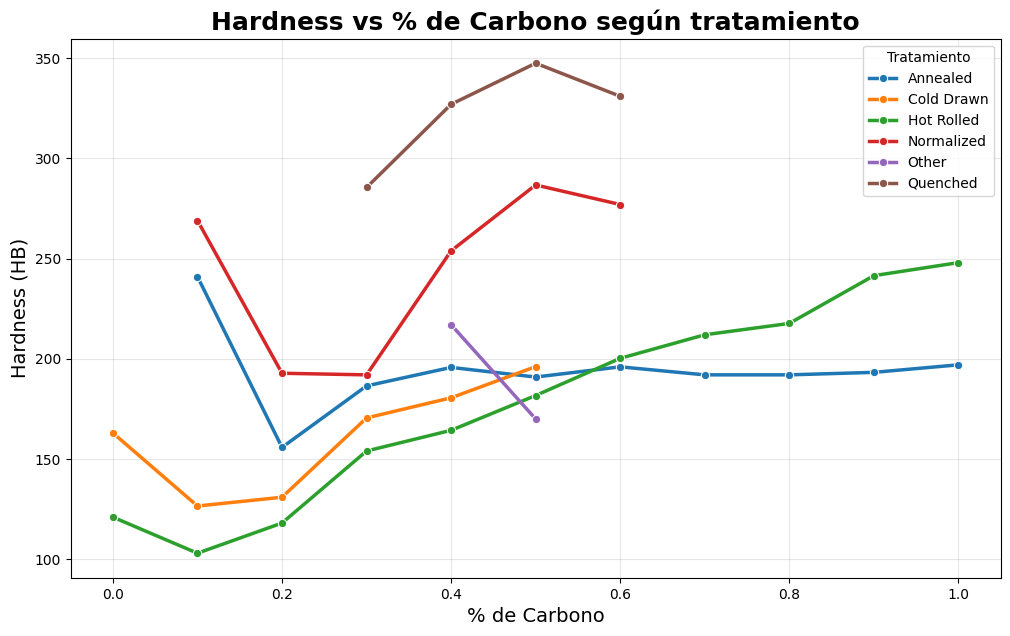

In [26]:
df_hard = df.groupby(
    ["Condition_simple", "C_round"]
)["Hardness (HB)"].mean().reset_index()

plt.figure(figsize=(12,7))

sns.lineplot(
    data=df_hard,
    x="C_round",
    y="Hardness (HB)",
    hue="Condition_simple",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Hardness vs % de Carbono según tratamiento",
    fontsize=18,
    weight="bold"
)

plt.xlabel("% de Carbono", fontsize=14)
plt.ylabel("Hardness (HB)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.legend(title="Tratamiento")

plt.show()

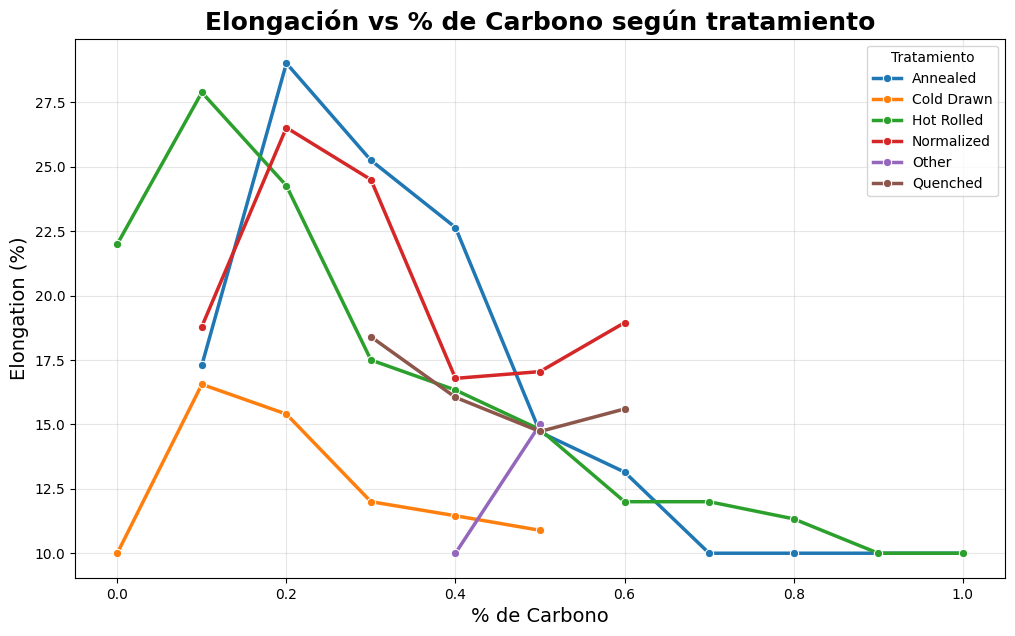

In [27]:
df_elong = df.groupby(
    ["Condition_simple", "C_round"]
)["Elongation (%)"].mean().reset_index()

plt.figure(figsize=(12,7))

sns.lineplot(
    data=df_elong,
    x="C_round",
    y="Elongation (%)",
    hue="Condition_simple",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Elongación vs % de Carbono según tratamiento",
    fontsize=18,
    weight="bold"
)

plt.xlabel("% de Carbono", fontsize=14)
plt.ylabel("Elongation (%)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.legend(title="Tratamiento")

plt.show()

C:\Users\drgoa\AppData\Local\Temp\ipykernel_24572\4234331677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


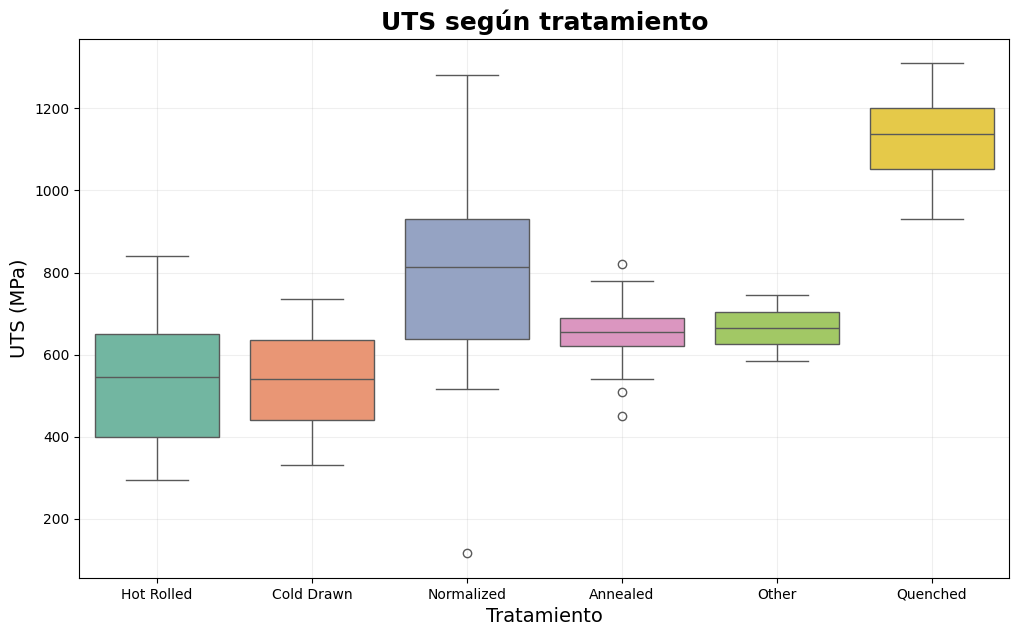

In [28]:
plt.figure(figsize=(12,7))

sns.boxplot(
    data=df,
    x="Condition_simple",
    y="UTS (MPa)",
    palette="Set2"
)

plt.title(
    "UTS según tratamiento",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Tratamiento", fontsize=14)
plt.ylabel("UTS (MPa)", fontsize=14)

plt.grid(True, alpha=0.2)

plt.show()

C:\Users\drgoa\AppData\Local\Temp\ipykernel_24572\3861310463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


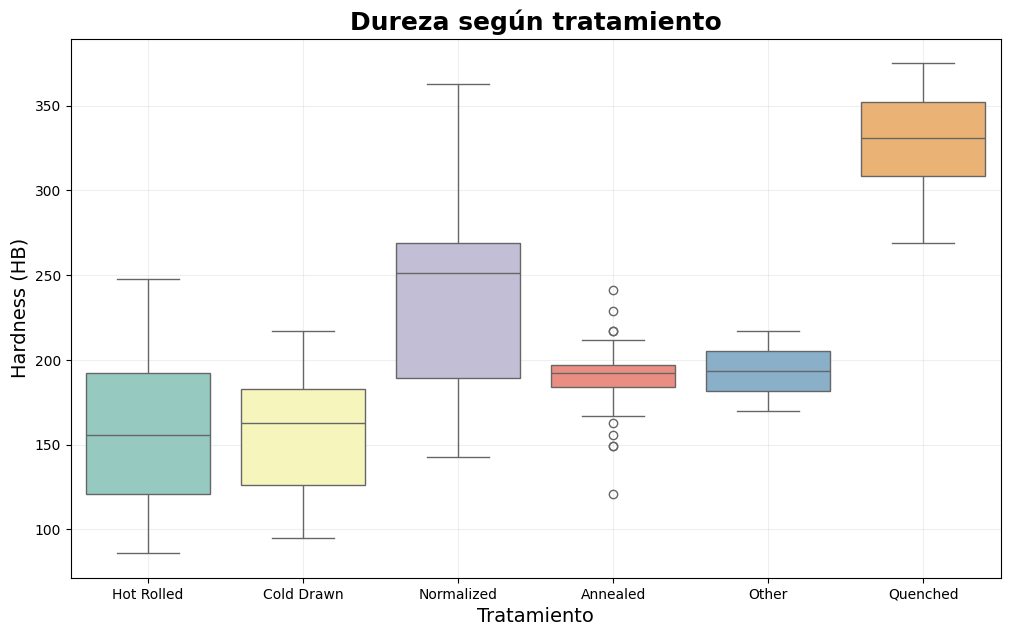

In [29]:
plt.figure(figsize=(12,7))

sns.boxplot(
    data=df,
    x="Condition_simple",
    y="Hardness (HB)",
    palette="Set3"
)

plt.title(
    "Dureza según tratamiento",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Tratamiento", fontsize=14)
plt.ylabel("Hardness (HB)", fontsize=14)

plt.grid(True, alpha=0.2)

plt.show()

C:\Users\drgoa\AppData\Local\Temp\ipykernel_24572\2755744601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


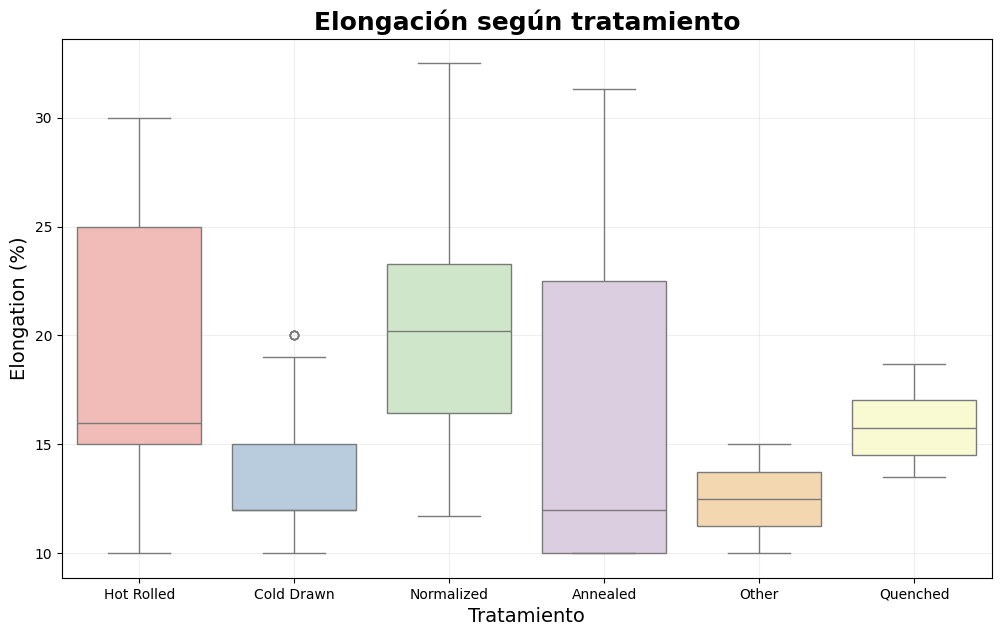

In [30]:
plt.figure(figsize=(12,7))

sns.boxplot(
    data=df,
    x="Condition_simple",
    y="Elongation (%)",
    palette="Pastel1"
)

plt.title(
    "Elongación según tratamiento",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Tratamiento", fontsize=14)
plt.ylabel("Elongation (%)", fontsize=14)

plt.grid(True, alpha=0.2)

plt.show()

# Tercera pregunta: influencia de la temperatura del tratamiento

In [31]:
# Extraer temperatura desde la columna Conditions

df["Temp_C"] = (
    df["Conditions"]
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

# Convertir a número
df["Temp_C"] = pd.to_numeric(df["Temp_C"])

# Verificar resultados
df[["Conditions", "Temp_C"]].head(15)

,Conditions,Temp_C
0,Hot rolled,NaN
1,Cold drawn,NaN
2,Hot rolled,NaN
3,Cold drawn,NaN
4,Hot rolled,NaN
5,Cold drawn,NaN
6,Hot rolled,NaN
7,Cold drawn,NaN
8,Hot rolled,NaN
9,Cold drawn,NaN


In [32]:
df[df["Temp_C"].notnull()][["Conditions", "Temp_C"]].head(20)
#Confirmamos que si estamos trabajando con temperaturas sin símbolos especiales que el código no pueda leer.

,Conditions,Temp_C
121,Normalized at 870 °C (1600 °F),870.0
122,Annealed at 800 °C (1475 T),800.0
140,Normalized at 870 °C (1600 °F),870.0
141,Annealed at 815 °C (1500 °F),815.0
142,Normalized at 870 °C (1600 °F),870.0
143,Annealed at 865 °C (1585 T),865.0
144,Water quenched from 855 °C (1575 T)\nand tempe...,855.0
145,Normalized at 870 °C (1600 °F),870.0
146,Annealed at 815 °C (1500 °F),815.0
147,Water quenched from 845 °C (1550 °F)\nand temp...,845.0


In [33]:
df_annealed = df[
    (df["Condition_simple"] == "Annealed") &
    (df["Temp_C"].notnull())
]
#Preparamos ambiente para generar las gráficas 

In [34]:
df_normalized = df[
    (df["Condition_simple"] == "Normalized") &
    (df["Temp_C"].notnull())
]

In [35]:
df_annealed[["Conditions", "Temp_C"]].head()

,Conditions,Temp_C
122,Annealed at 800 °C (1475 T),800.0
141,Annealed at 815 °C (1500 °F),815.0
143,Annealed at 865 °C (1585 T),865.0
146,Annealed at 815 °C (1500 °F),815.0
149,Annealed at 830 °C (1525 T),830.0


In [36]:
df_normalized[["Conditions", "Temp_C"]].head()

,Conditions,Temp_C
121,Normalized at 870 °C (1600 °F),870.0
140,Normalized at 870 °C (1600 °F),870.0
142,Normalized at 870 °C (1600 °F),870.0
145,Normalized at 870 °C (1600 °F),870.0
148,Normalized at 870 °C (1600 °F),870.0


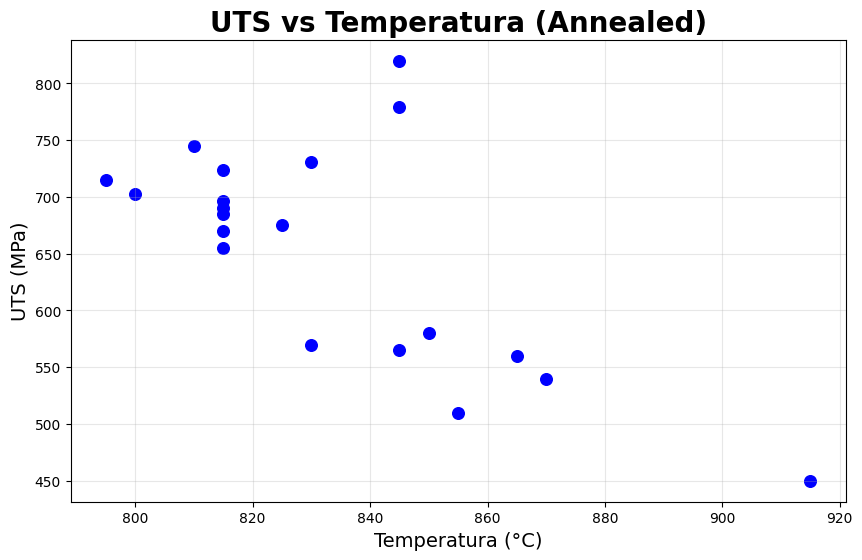

In [37]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_annealed["Temp_C"],
    df_annealed["UTS (MPa)"],
    color="blue",
    s=70
)

plt.title(
    "UTS vs Temperatura (Annealed)",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Temperatura (°C)", fontsize=14)
plt.ylabel("UTS (MPa)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.show()

#Aquí damos el gráfico con los datos cargados previamente, asi se vería de manera completa

In [38]:
annealed_avg = (
    df_annealed
    .groupby("Temp_C")[["UTS (MPa)"]]
    .mean()
    .reset_index()
)

annealed_avg
#Aquí damos el promedio de los datos para generar una mejor gráfica.

,Temp_C,UTS (MPa)
0,795.0,715.000000
1,800.0,703.000000
2,810.0,745.000000
3,815.0,686.666667
4,825.0,675.000000
5,830.0,650.500000
6,845.0,721.333333
7,850.0,580.000000
8,855.0,510.000000
9,865.0,560.000000


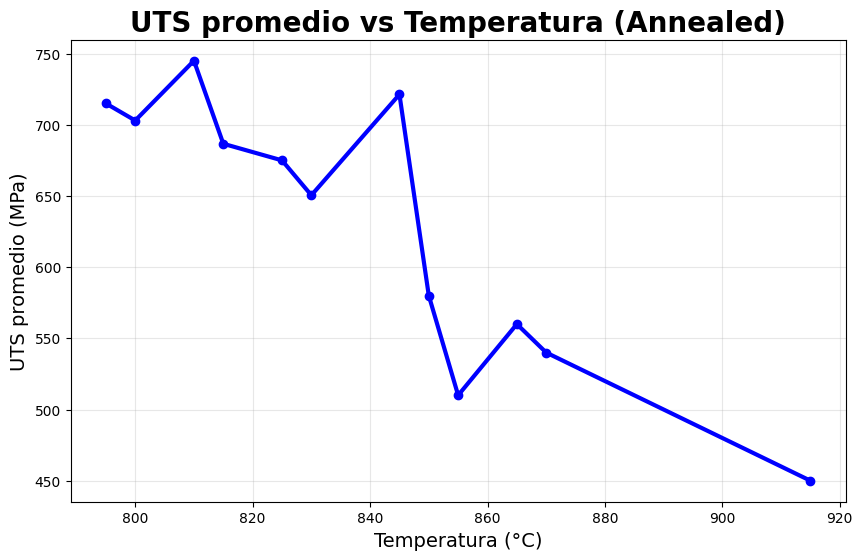

In [39]:
plt.figure(figsize=(10,6))

plt.plot(
    annealed_avg["Temp_C"],
    annealed_avg["UTS (MPa)"],
    marker="o",
    linewidth=3,
    color="blue"
)

plt.title(
    "UTS promedio vs Temperatura (Annealed)",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Temperatura (°C)", fontsize=14)
plt.ylabel("UTS promedio (MPa)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.show()

#Gráfica mejorada visualmente.

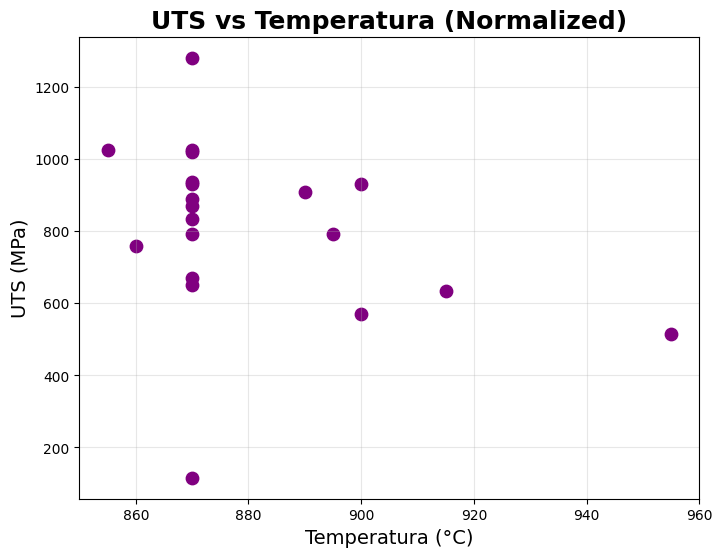

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_normalized["Temp_C"],
    df_normalized["UTS (MPa)"],
    color="purple",
    s=80
)

plt.title(
    "UTS vs Temperatura (Normalized)",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Temperatura (°C)", fontsize=14)
plt.ylabel("UTS (MPa)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.show()

#Para la parte de normalized este es el gráfco colocando todos los puntos registrados anteriormente. 

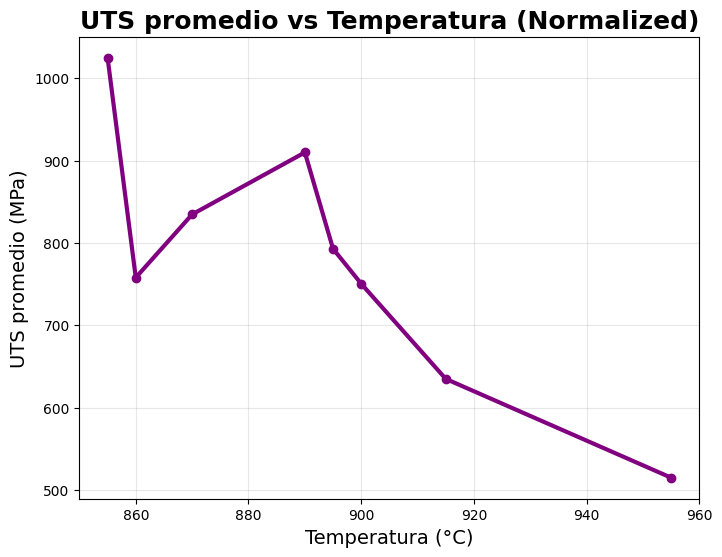

In [41]:
normalized_avg = (
    df_normalized
    .groupby("Temp_C")[["UTS (MPa)"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,6))

plt.plot(
    normalized_avg["Temp_C"],
    normalized_avg["UTS (MPa)"],
    marker="o",
    linewidth=3,
    color="purple"
)

plt.title(
    "UTS promedio vs Temperatura (Normalized)",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Temperatura (°C)", fontsize=14)
plt.ylabel("UTS promedio (MPa)", fontsize=14)

plt.grid(True, alpha=0.3)

plt.show()

#Y aqui se ve el gráfico de una mejor manera mas limpia visualmente. 

# Cuarta pregunta: qué influye más, el %C o el tratamiento térmico  

In [42]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Modelo ANOVA
modelo = ols(
    'Q("UTS (MPa)") ~ C(Condition_simple) + C_pct',
    data=df
).fit()

anova_tabla = sm.stats.anova_lm(modelo, typ=2)

print(anova_tabla)

                           sum_sq     df           F        PR(>F)
C(Condition_simple)  3.846169e+06    5.0   66.759620  1.958132e-39
C_pct                1.469521e+06    1.0  127.535515  8.833809e-23
Residual             2.108607e+06  183.0         NaN           NaN
